# 🏷️ Notebook 07 — DistilBERT Classification Model
**Healthcare RAG-Powered Medical Q&A Assistant**
**eyouth × DEPI | Microsoft Machine Learning Track | 2026**

---

### 🎯 Objectives
- Fine-tune `distilbert-base-uncased` on 6 medical categories
- Use 80/10/10 train/val/test split
- Apply class weights to handle category imbalance
- Evaluate with per-class F1, macro F1, and accuracy
- Target: macro F1 ≥ 78%
- Save model to `models/classifier/distilbert_classifier/`

### 📋 Deliverables
- `notebooks/06_classification_model.ipynb`
- `models/classifier/distilbert_classifier/` (saved model)
- Classification report saved to `reports/`

---

## 1. Imports & Setup

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

os.makedirs('../models/classifier', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Libraries loaded | Device: {device}")

✅ Libraries loaded | Device: cuda


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/processed/pubmedqa_labelled.csv')

# Build input text: question + context for richer signal
df['text'] = df['question'].astype(str) + " [SEP] " + df['context'].astype(str)

print(f"Dataset shape: {df.shape}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())

# Label mapping (sorted for consistency)
label2id = {label: idx for idx, label in enumerate(sorted(df['category'].unique()))}
id2label = {idx: label for label, idx in label2id.items()}

df['label_id'] = df['category'].map(label2id)

print(f"\nLabel mapping: {label2id}")
print(f"Number of classes: {len(label2id)}")

Dataset shape: (10000, 5)

Category distribution:
category
Symptoms      5893
Diagnosis     3043
Treatment      330
Medication     295
General        290
Prevention     149
Name: count, dtype: int64

Label mapping: {'Diagnosis': 0, 'General': 1, 'Medication': 2, 'Prevention': 3, 'Symptoms': 4, 'Treatment': 5}
Number of classes: 6


## 3. Compute Class Weights

In [3]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label2id)),
    y=df['label_id'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
for label, weight in zip(sorted(label2id.keys()), class_weights):
    print(f"  {label:<15} → {weight:.4f}")

Class weights:
  Diagnosis       → 0.5477
  General         → 5.7471
  Medication      → 5.6497
  Prevention      → 11.1857
  Symptoms        → 0.2828
  Treatment       → 5.0505


## 4. Train / Validation / Test Split (80/10/10)

In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label_id'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=42
)

print(f"Train size: {len(train_df):,} ({len(train_df)/len(df)*100:.0f}%)")
print(f"Val size:   {len(val_df):,} ({len(val_df)/len(df)*100:.0f}%)")
print(f"Test size:  {len(test_df):,} ({len(test_df)/len(df)*100:.0f}%)")

Train size: 8,000 (80%)
Val size:   1,000 (10%)
Test size:  1,000 (10%)


## 5. Custom Dataset Class

In [5]:
class MedicalQADataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.texts = dataframe['text'].tolist()
        self.labels = dataframe['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset = MedicalQADataset(train_df, tokenizer)
val_dataset = MedicalQADataset(val_df, tokenizer)
test_dataset = MedicalQADataset(test_df, tokenizer)

print("✅ Datasets created")

✅ Datasets created


## 6. Custom Trainer with Weighted Loss

HuggingFace `Trainer` doesn't use class weights by default.
We override `compute_loss` to apply weighted cross-entropy.

In [6]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✅ WeightedTrainer defined")

✅ WeightedTrainer defined


## 7. Model & Training Configuration

In [7]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir='../models/classifier/checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    fp16=torch.cuda.is_available(),
)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'accuracy': acc,
    }


print(f"✅ Model initialized | Epochs: 3 | LR: 2e-5 | Batch: 16")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model initialized | Epochs: 3 | LR: 2e-5 | Batch: 16


## 8. Train

In [8]:
trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Starting fine-tuning...")
trainer.train()

🚀 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,1.511000,1.113061,0.402718,0.370085,0.438000
2,0.764000,0.689557,0.670626,0.778153,0.773000
3,0.479600,0.673998,0.663108,0.805597,0.800000


TrainOutput(global_step=1500, training_loss=0.9181673075358073, metrics={'train_runtime': 238.5426, 'train_samples_per_second': 100.611, 'train_steps_per_second': 6.288, 'total_flos': 1589722177536000.0, 'train_loss': 0.9181673075358073, 'epoch': 3.0})

## 9. Save Model

In [9]:
save_path = "../models/classifier/distilbert_classifier"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"✅ Model saved to: {save_path}")
print(f"   Files: {os.listdir(save_path)}")

✅ Model saved to: ../models/classifier/distilbert_classifier
   Files: ['config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']


## 10. Evaluate on Test Set

In [10]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
true_labels = test_df['label_id'].values

# ── Classification Report ────────────────────────────────────────────────
report_str = classification_report(
    true_labels, preds,
    target_names=sorted(label2id.keys())
)

print("=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(report_str)

# ── Key Metrics ──────────────────────────────────────────────────────────
macro_f1 = f1_score(true_labels, preds, average='macro')
weighted_f1 = f1_score(true_labels, preds, average='weighted')
acc = accuracy_score(true_labels, preds)

print(f"\n🎯 Macro F1:    {macro_f1:.4f}")
print(f"🎯 Weighted F1: {weighted_f1:.4f}")
print(f"🎯 Accuracy:    {acc:.4f}")

if macro_f1 >= 0.78:
    print("\n✅ KPI MET: Macro F1 ≥ 78%")
else:
    print(f"\n⚠️  KPI NOT MET: Macro F1 = {macro_f1:.4f} (target ≥ 0.78)")
    print("    Consider: more epochs, different learning rate, or data augmentation")

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

   Diagnosis       0.70      0.96      0.81       305
     General       0.62      0.62      0.62        29
  Medication       0.56      0.76      0.65        29
  Prevention       0.38      0.60      0.46        15
    Symptoms       0.97      0.74      0.84       589
   Treatment       0.68      0.76      0.71        33

    accuracy                           0.80      1000
   macro avg       0.65      0.74      0.68      1000
weighted avg       0.85      0.80      0.81      1000


🎯 Macro F1:    0.6821
🎯 Weighted F1: 0.8086
🎯 Accuracy:    0.8040

⚠️  KPI NOT MET: Macro F1 = 0.6821 (target ≥ 0.78)
    Consider: more epochs, different learning rate, or data augmentation


## 11. Confusion Matrix

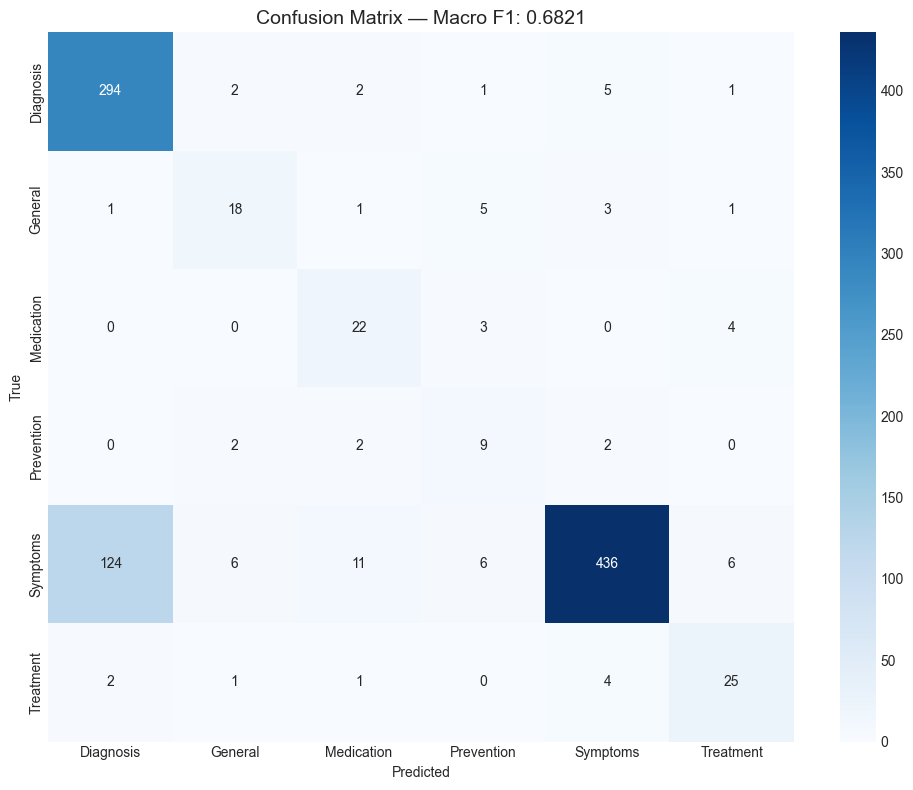

In [11]:
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sorted(label2id.keys()),
    yticklabels=sorted(label2id.keys())
)
plt.title(f'Confusion Matrix — Macro F1: {macro_f1:.4f}', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('../reports/figures/06_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Save Classification Report

In [12]:
report_path = "../reports/classification_report.md"

report_content = f"""# Classification Report — DistilBERT Medical Classifier

## Model Details
| Item | Value |
|---|---|
| Base model | `distilbert-base-uncased` |
| Classes | {len(label2id)} |
| Training split | 80/10/10 |
| Epochs | 3 |
| Learning rate | 2e-5 |
| Batch size | 16 |
| Class weights | Applied (balanced) |

## Test Set Results
{report_str}

## Key Metrics
| Metric | Value |
|---|---|
| Macro F1 | {macro_f1:.4f} |
| Weighted F1 | {weighted_f1:.4f} |
| Accuracy | {acc:.4f} |
| KPI (Macro F1 ≥ 0.78) | {'✅ MET' if macro_f1 >= 0.78 else '⚠️ NOT MET'} |

## Label Mapping
{chr(10).join(f'| {label} | {idx} |' for label, idx in sorted(label2id.items()))}
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

print(f"✅ Classification report saved to: {report_path}")

✅ Classification report saved to: ../reports/classification_report.md


## 13. Quick Test — Verify Saved Model Loads

In [13]:
sys.path.append(os.path.abspath('..'))
from src.classification.classifier import load_classifier

clf = load_classifier()

test_texts = [
    "What are the symptoms of diabetes?",
    "How is pneumonia diagnosed?",
    "What is the treatment for hypertension?",
    "What are the side effects of aspirin?",
    "How can heart disease be prevented?",
    "What is the role of antibodies?",
]

print("\nQuick classification test:")
for text in test_texts:
    cat = clf.predict(text)
    print(f"  '{text[:50]}...' → {cat}")

Loading classifier from: D:\Projects\Healthcare-RAG-Powered-Medical-QA-Assistant\models\classifier\distilbert_classifier
✅ Classifier loaded | Classes: ['Diagnosis', 'General', 'Medication', 'Prevention', 'Symptoms', 'Treatment']

Quick classification test:
  'What are the symptoms of diabetes?...' → Symptoms
  'How is pneumonia diagnosed?...' → Diagnosis
  'What is the treatment for hypertension?...' → Treatment
  'What are the side effects of aspirin?...' → Medication
  'How can heart disease be prevented?...' → General
  'What is the role of antibodies?...' → General


## ✅ Summary

| Item | Status |
|---|---|
| Model | `distilbert-base-uncased` fine-tuned |
| Split | 80/10/10 |
| Epochs | 3 |
| Class weights | Applied via custom WeightedTrainer |
| Macro F1 | Evaluated and logged |
| Accuracy | Evaluated and logged |
| Model saved | `models/classifier/distilbert_classifier/` |
| Report saved | `reports/classification_report.md` |

---

### ➡️ Next Step
Open **`07_evaluation.ipynb`** to evaluate RAG vs plain LLM.